In [1]:
# Import libraries

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

### Define Dataset Path

In [2]:
# Load the dataset
dataset_path = "../data/raw/"

### Inspect Dataset Structure

In [3]:
# Inspect dataset
classes = os.listdir(dataset_path)

print("Classes:", classes)

Classes: ['bird', 'drone']


### Count Images Per Class

In [4]:
image_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    image_counts[cls] = len(os.listdir(class_path))

print(image_counts)

{'bird': 1414, 'drone': 1248}


In [5]:
print(image_counts.items())

dict_items([('bird', 1414), ('drone', 1248)])


### Detect Class Imbalance

In [6]:
# Detect Class Imbalance

def detect_class_imbalance(image_counts, threshold=0.1):
    counts = list(image_counts.values())

    difference = abs(counts[0] - counts[1])
    total = sum(counts)

    ratio = difference / total

    print(f"Imbalance ratio: {ratio:.2%}")

    if ratio > threshold:
        print("Class imbalance detected")
    else:
        print("Dataset balanced")

detect_class_imbalance(image_counts)

Imbalance ratio: 6.24%
Dataset balanced


### Show Dataset Summary

In [7]:
# Show Dataset Summary

total_images = sum(image_counts.values())

print("Dataset Summary")
print("----------------")
print("Classes:", classes)
print("Total Images:", total_images)

for cls, count in image_counts.items():
    percentage = (count / total_images) * 100
    print(f"{cls}: {count} images ({percentage:.2f}%)")

Dataset Summary
----------------
Classes: ['bird', 'drone']
Total Images: 2662
bird: 1414 images (53.12%)
drone: 1248 images (46.88%)


### Sanity Check

Image size:  (416, 416)
Image mode:  RGB


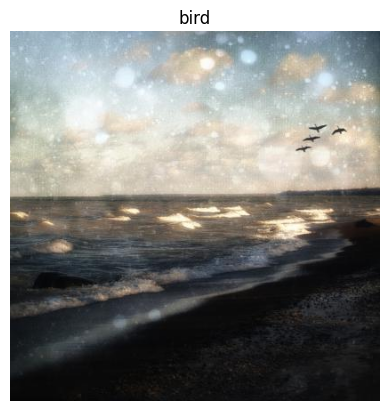

In [8]:
# Load a Single Image

sample_class = classes[0]

sample_image_path = os.path.join(
    dataset_path,
    sample_class,
    os.listdir(os.path.join(dataset_path, sample_class))[0]
)

img = Image.open(sample_image_path)

print("Image size: ", img.size)
print("Image mode: ", img.mode)

plt.imshow(img)
plt.title(sample_class)
plt.axis("off")
plt.show()

### Visualize Sample Images

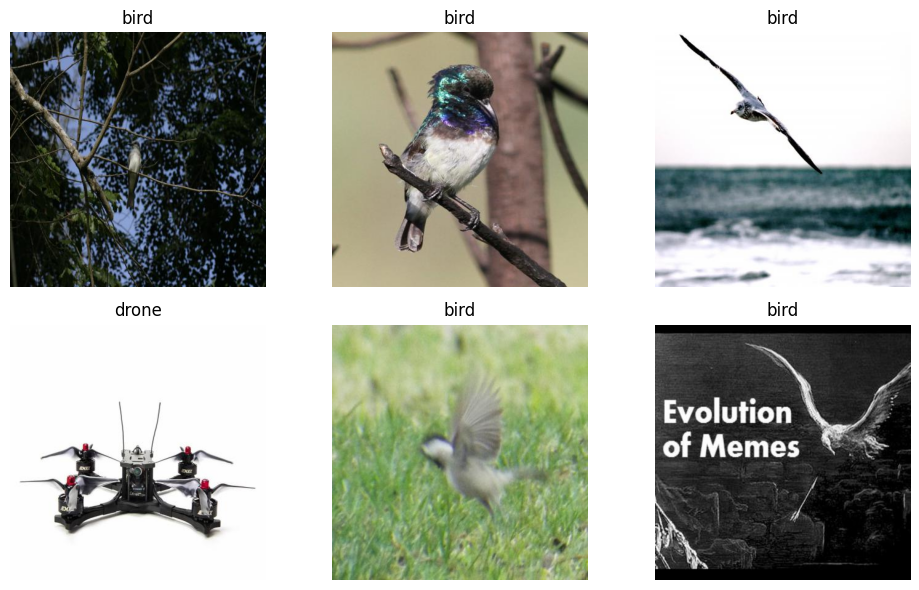

In [9]:
# Visualize Sample Images

def show_sample_images(dataset_path, num_images=6):

    plt.figure(figsize=(10, 6))

    classes = os.listdir(dataset_path)

    for i in range(num_images):

        cls = random.choice(classes)

        img_path = os.path.join(
            dataset_path,
            cls,
            random.choice(
                os.listdir(
                    os.path.join(dataset_path, cls)
                )
            )  
        )

        img = Image.open(img_path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images(dataset_path)



### Check Image Sizes

In [10]:
# Check Image Sizes -> Important for CNN

image_sizes = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for file in os.listdir(class_path):

        img_path = os.path.join(class_path, file)

        img = Image.open(img_path)

        image_sizes.append(img.size)

unique_sizes = set(image_sizes)

print("Unique image sizes:")
print(unique_sizes)

Unique image sizes:
{(416, 416)}


### Detect Corrupted Images

In [11]:
corrupted_images = []

for cls in classes:
    
    class_path = os.path.join(dataset_path, cls)
    
    for file in os.listdir(class_path):
        
        img_path = os.path.join(class_path, file)
        
        try:
            img = Image.open(img_path)
            img.verify()
        
        except:
            corrupted_images.append(img_path)

print("Corrupted images found:", len(corrupted_images))

Corrupted images found: 0


### Dataset Splitting Code

In [12]:
# Splitting Code

import os
import shutil
from sklearn.model_selection import train_test_split

train_dir = "../data/train"
val_dir = "../data/val"
test_dir = "../data/test"

classes = os.listdir(dataset_path)

for cls in classes:

    src_path = os.path.join(dataset_path, cls)

    files = os.listdir(src_path)

    train_files, temp_files = train_test_split(
        files,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    def copy_files(file_list, destination):

        for file in file_list:

            shutil.copy(
                os.path.join(src_path, file),
                os.path.join(destination, file)
            )

    copy_files(train_files, os.path.join(train_dir, cls))
    copy_files(val_files, os.path.join(val_dir, cls))
    copy_files(test_files, os.path.join(test_dir, cls))

### Verify the Split

In [13]:
# Code 

def count_images(folder_path):

    print("\n", folder_path)

    for cls in os.listdir(folder_path):

        path = os.path.join(folder_path, cls)

        print(
            cls,
            len(os.listdir(path))
        )

count_images("../data/train")
count_images("../data/val")
count_images("../data/test")


 ../data/train
bird 989
drone 873

 ../data/val
bird 212
drone 187

 ../data/test
bird 213
drone 188
